# Obligatorio — Análisis Predictivo de Series Temporales — Curso 2026

## Posgrado de Big Data e Inteligencia Artificial — Universidad ORT Uruguay

---

**Fecha de entrega:** 6/7/2026 por el sistema de Gestión.

Se debe entregar un PDF con los avances a la fecha. Pueden seguir trabajando en el repo y solución hasta el 13/7/2026.

---

### Integrantes:

* Ramiro Sanes (368397)
* Joaquin Guerra (307854)

---

## Introducción

En este obligatorio se analiza la serie de consumo eléctrico diario de la región **PJME** (PJM East), que corresponde a una parte de la red de transmisión eléctrica del este de los Estados Unidos, operada por PJM Interconnection LLC.

Los datos cubren el período **2002–2017** (16 años completos, ~5800 observaciones diarias) y provienen del dataset público disponible en [Kaggle](https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption), aquí ya procesados a frecuencia diaria.

El objetivo del trabajo es construir, evaluar y comparar distintos modelos de predicción para esta serie, incorporando progresivamente más estructura. Para ello, el trabajo se organiza en varias partes, buscando construir diferentes modelos y poder comparar su poder predictivo. Se sugiere tomar como datos de entrenamiento los datos hasta 2015 y utilizar los últimos 2 años para test.

## Carga de datos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = [14, 4]
plt.rcParams['axes.grid'] = True

In [2]:
# Cargar datos
data = pd.read_csv('data/pjme_daily.csv', parse_dates=['date'], index_col='date')
data.index.freq = 'D' #le asigno frecuencia diaria al indice
pjme=pd.Series(data["consumo_MW"])
print(f"Serie cargada: {len(pjme)} observaciones ({pjme.index.min().date()} a {pjme.index.max().date()})")
pjme.head()

Serie cargada: 5844 observaciones (2002-01-01 a 2017-12-31)


date
2002-01-01    31080.7
2002-01-02    34261.5
2002-01-03    34511.9
2002-01-04    33715.5
2002-01-05    30405.1
Freq: D, Name: consumo_MW, dtype: float64

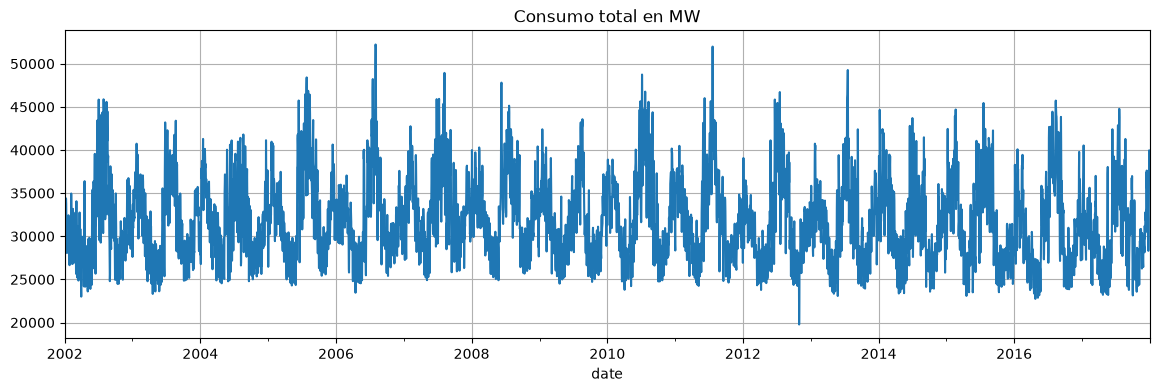

In [3]:
pjme.plot();
plt.title("Consumo total en MW");

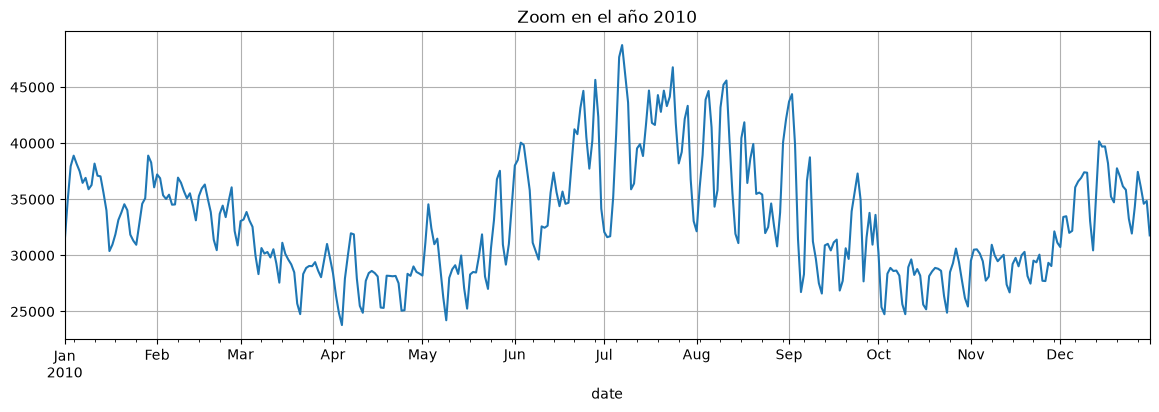

In [4]:
zoom = pjme['2010']
zoom.plot()
plt.title("Zoom en el año 2010");

## Parte I — Análisis exploratorio

En esta parte se busca construir un modelo que capture el comportamiento sistemático de la serie a partir de funciones del tiempo. En particular se debe explorar:

 * Si la serie presenta tendencias visibles.
 * Si la serie presenta correlaciones de corto o largo plazo.
 * Si hay efectos estacionales o periódicos regulares. *Sugerencia:* observe que las series presentan *2 picos* por año correspondientes a los picos de consumo en invierno y verano respectivamente.
 * Si hay efectos de días especiales, por ejemplo fines de semana donde hay menos consumo. *Sugerencia:* Agrupe la serie por día de la semana y realice un `boxplot` para ver el comportamiento.

En base a los efectos anteriores, proponga un modelo lineal adecuado para la serie. Analice los resultados del ajuste, discuta el comportamiento de los residuos sobre el conjunto de entrenamiento, calcule el RMSE del ajuste y el RMSE del modelo en los datos de test.

### Solución — Parte I

Trabajamos con el split sugerido por la letra: **train hasta 2015-12-31** y **test 2016–2017**. Todo el análisis exploratorio y el ajuste se realizan **sobre train**; el test lo reservamos para medir la predicción. La métrica en todo el trabajo es el RMSE.

Exploramos en orden lo que pide la letra: tendencia, correlaciones de corto/largo plazo (ACF/PACF), periodicidades (periodograma) y efecto del día de la semana (boxplot). Con esa evidencia proponemos un **modelo lineal determinístico** (funciones del tiempo) estimado por mínimos cuadrados.

In [ ]:
# ====== Funciones comunes para todo el obligatorio ======
import statsmodels.api as sm
from statsmodels.tsa.api import ARIMA, UnobservedComponents
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.api import acorr_ljungbox

def rmse(y, yhat):
    y = np.asarray(y, dtype=float).ravel()
    yhat = np.asarray(yhat, dtype=float).ravel()
    return np.sqrt(np.mean((y - yhat) ** 2))

# ------ Funciones vistas en el curso ------
def periodogram(x, sampling_frequency=1):
    """Calcula y grafica el periodograma escalado (función del curso)."""
    n = x.size
    P = 4/n**2 * np.abs(np.fft.fft(x))**2
    P = P[0:round(n/2)]
    f = np.arange(0, round(n/2))/n * sampling_frequency
    plt.plot(f, P)
    plt.xlabel("Frecuencia")
    plt.ylabel("Potencia")

def spectrum(x, sampling_frequency=1, nfreq=10):
    """Devuelve las frecuencias más relevantes del periodograma (función del curso)."""
    n = x.size
    nfreq = np.minimum(nfreq, round(n/2))
    P = 4/n**2 * np.abs(np.fft.fft(x))**2
    P = P[0:round(n/2)]
    f = np.arange(0, round(n/2))/n * sampling_frequency
    index = np.argsort(P)[::-1]
    return pd.DataFrame({"Frecuencia": f[index[0:nfreq]], "Potencia": P[index[0:nfreq]]})

def ccf(x, y, max_lag, ax=None, **kwargs):
    """Correlación cruzada con lags positivos y negativos (función del curso)."""
    lags = np.arange(-max_lag, max_lag + 1)
    backwards = sm.tsa.ccf(x[::-1], y[::-1], adjusted=False)[max_lag::-1]
    forwards = sm.tsa.ccf(x, y, adjusted=False)[:max_lag + 1]
    vals = np.r_[backwards[:-1], forwards]
    if ax is None:
        ax = plt.gca()
    ax.stem(lags, vals, basefmt="k")
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    conf_level = 1.96 / np.sqrt(x.shape[0])
    ax.fill_between(lags, conf_level, -conf_level, alpha=0.25)
    ax.set_xlabel("LAG")
    ax.set_ylabel("CCF")
    return ax

# Split temporal: train hasta 2015, test 2016-2017 (sin barajar: es una serie temporal)
train_end = '2015-12-31'
y_train = pjme.loc[:train_end]
y_test  = pjme.loc['2016-01-01':]
print(f"Train: {y_train.index.min().date()} a {y_train.index.max().date()}  ({len(y_train)} obs)")
print(f"Test : {y_test.index.min().date()} a {y_test.index.max().date()}  ({len(y_test)} obs)")

Train: 2002-01-01 a 2015-12-31  (5113 obs)
Test : 2016-01-01 a 2017-12-31  (731 obs)


**Tendencia.** Suavizamos con una media móvil anual para ver el nivel de fondo de la serie sin el ciclo estacional.

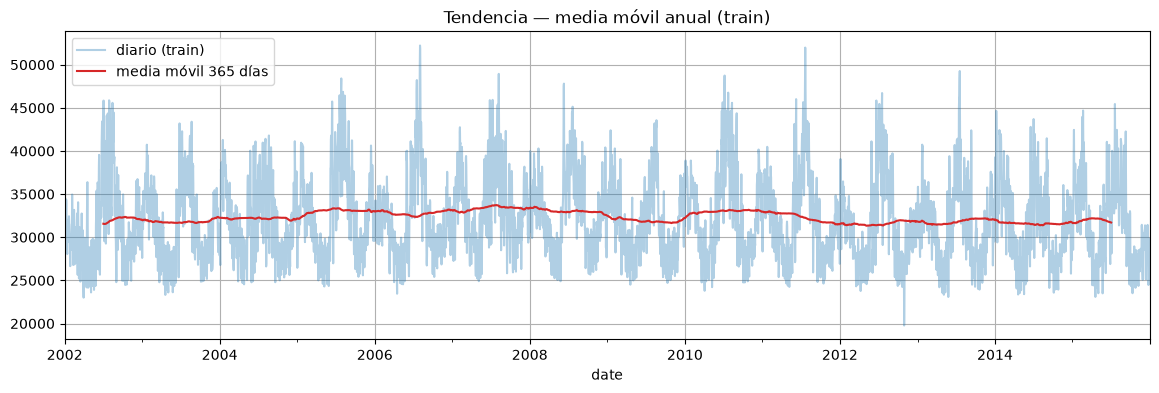

In [6]:
# Tendencia: media móvil anual sobre el conjunto de entrenamiento
fig, ax = plt.subplots()
y_train.plot(ax=ax, alpha=0.35, label='diario (train)')
y_train.rolling(365, center=True).mean().plot(ax=ax, color='C3', label='media móvil 365 días')
ax.set_title('Tendencia — media móvil anual (train)'); ax.legend();

**Correlaciones de corto y largo plazo.** Miramos la ACF a pocos lags (dependencia de corto plazo) y a ~2 años de lags (estructura de largo plazo), junto con la PACF. Usamos `bartlett_confint=False` para tener el intervalo de confianza correcto.

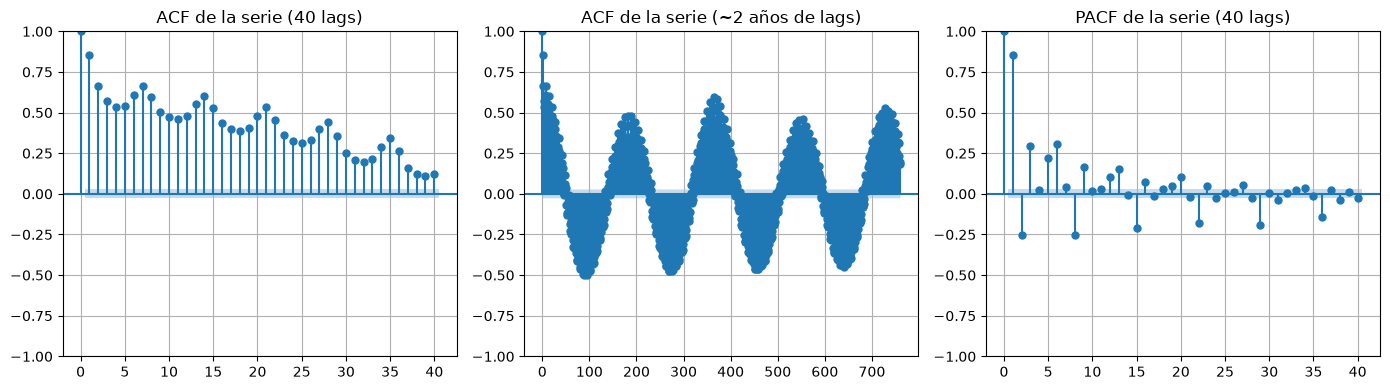

In [7]:
# Autocorrelación de la serie: corto plazo y largo plazo
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
plot_acf(y_train, lags=40, bartlett_confint=False, ax=axes[0])
axes[0].set_title('ACF de la serie (40 lags)')
plot_acf(y_train, lags=760, bartlett_confint=False, ax=axes[1])
axes[1].set_title('ACF de la serie (~2 años de lags)')
plot_pacf(y_train, lags=40, ax=axes[2])
axes[2].set_title('PACF de la serie (40 lags)')
plt.tight_layout()

La ACF a lag 1 es 0.86 y decae lentamente: hay fuerte **correlación de corto plazo** (la demanda de un día se parece mucho a la del día anterior, en buena parte por la persistencia del clima). Sobre ese decaimiento se observan **ondulaciones cada 7 lags** (correlación semanal) y, mirando ~2 años de lags, la ACF vuelve a subir hasta ~0.53 en el lag 365 (**ciclo anual**), con un pico intermedio en ~182 días: medio año después la correlación también es alta porque la serie tiene **dos picos por año** (un día de pleno invierno se parece a uno de pleno verano). En resumen: correlaciones de corto y de largo plazo, estas últimas dominadas por estacionalidad.

**Periodicidades — periodograma.** Para identificar las frecuencias presentes usamos el periodograma visto en el curso, sobre la serie de train **centrada**. Expresamos las frecuencias en **ciclos por año** (`sampling_frequency=365.25`).

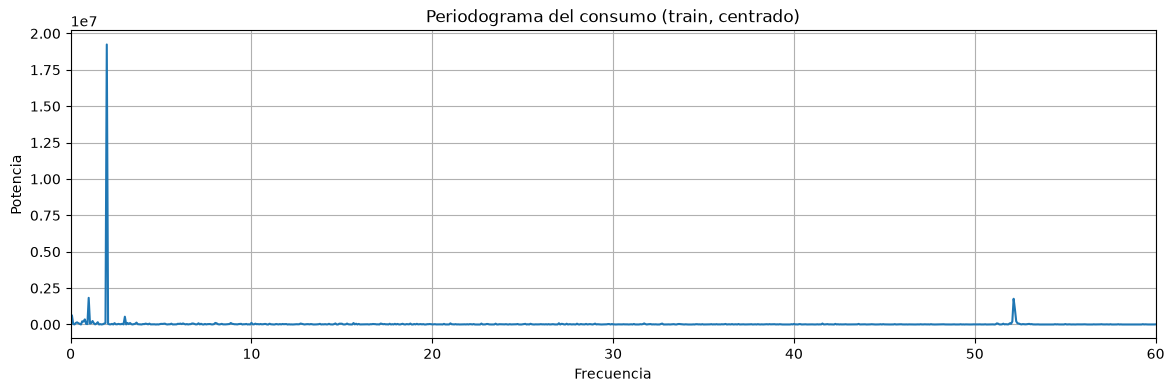

,Frecuencia,Potencia
0,2.000196,1.923952e+07
1,1.000098,1.832159e+06
2,52.147956,1.767005e+06
3,52.219392,1.052471e+06
4,104.367348,8.748289e+05
5,0.071436,6.281838e+05
6,3.000293,5.354575e+05
7,0.785791,3.508189e+05


In [8]:
# Periodograma de la serie centrada (frecuencias en ciclos por año)
yc_per = (y_train - y_train.mean()).values
plt.figure()
periodogram(yc_per, sampling_frequency=365.25)
plt.xlim(0, 60)
plt.title('Periodograma del consumo (train, centrado)')
plt.show()
spectrum(yc_per, sampling_frequency=365.25, nfreq=8)

**Lectura del periodograma.** El pico dominante está en $f=2$ ciclos/año — la componente **semianual** que genera los dos picos de invierno y verano — seguido por $f=1$ (ciclo anual) y por $f\approx 52.2 = 365.25/7$ ciclos/año, la **frecuencia semanal**. Aparece también $f=3$ con potencia mucho menor.

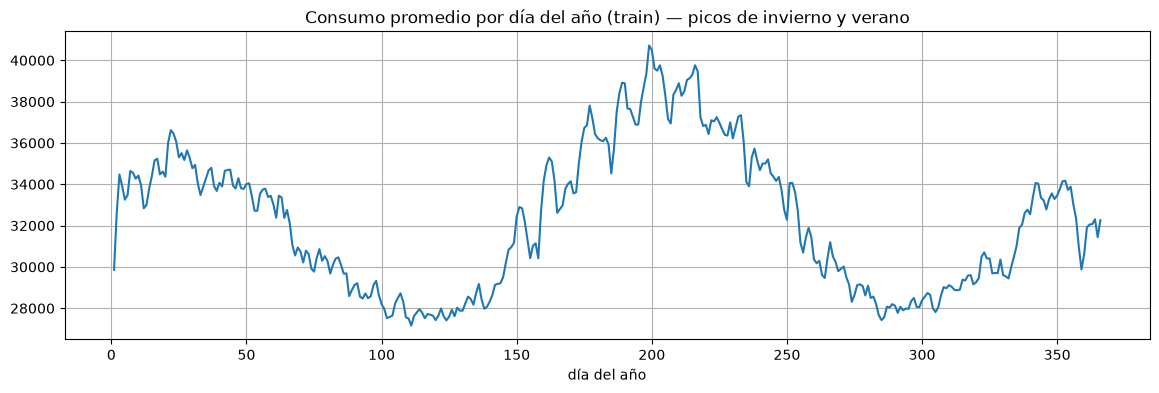

In [9]:
# Estacionalidad anual: promedio por día del año -> se ven los 2 picos (invierno y verano)
doy = y_train.groupby(y_train.index.dayofyear).mean()
doy.plot(title='Consumo promedio por día del año (train) — picos de invierno y verano')
plt.xlabel('día del año');

**Efecto del día de la semana.** Agrupamos por día de la semana y hacemos el `boxplot` que sugiere la letra, junto con la media por día.

dia
0    32879.0
1    33494.0
2    33498.0
3    33276.0
4    32821.0
5    30253.0
6    29502.0
Name: consumo, dtype: float64


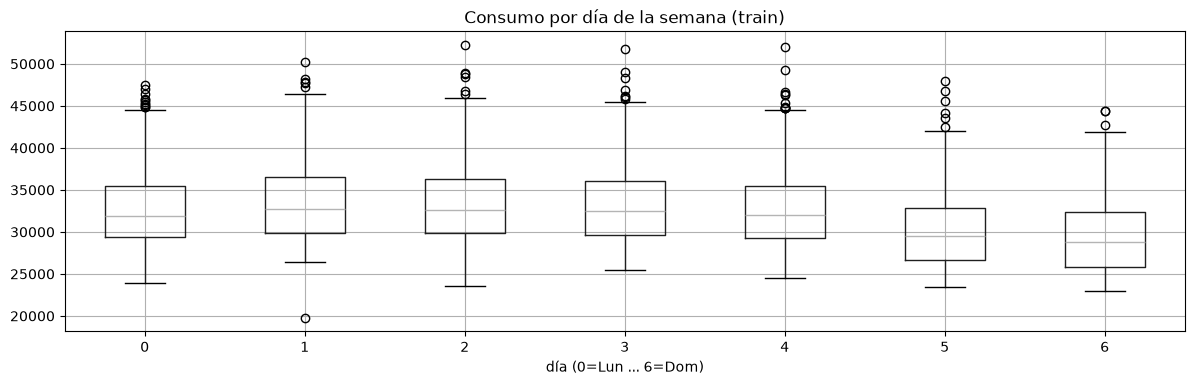

In [10]:
# Efecto día de la semana (0=Lun ... 6=Dom) sobre train
df_dia = pd.DataFrame({'consumo': y_train.values, 'dia': y_train.index.dayofweek})
print(df_dia.groupby('dia')['consumo'].mean().round(0))
df_dia.boxplot(column='consumo', by='dia')
plt.title('Consumo por día de la semana (train)'); plt.suptitle(''); plt.xlabel('día (0=Lun ... 6=Dom)');

El consumo cae fuerte el fin de semana (sábado ~30.300 MW y domingo ~29.500 MW, contra ~33.300–33.500 MW de martes a jueves), y además los días hábiles no son todos iguales: lunes y viernes quedan levemente por debajo del bloque martes–jueves (efecto "borde" del fin de semana). Por eso, en lugar de una única dummy de fin de semana usamos un **factor por día de la semana** (6 dummies con el lunes como referencia), para capturar también las diferencias entre días hábiles.

**Modelo lineal propuesto.** Con la evidencia anterior (tendencia suave, ciclo anual con dos picos, efecto por día de la semana) proponemos:

$$x_t = \beta_0 + \beta_1 \frac{t}{365.25} + \sum_{k=1}^{2}\left[a_k \cos\!\left(2\pi k \frac{t}{365.25}\right) + b_k \sin\!\left(2\pi k \frac{t}{365.25}\right)\right] + \sum_{j} \gamma_j\, D_j(t) + w_t$$

donde $D_j(t)$ son variables *dummy* por día de la semana con el lunes como referencia (regresión con factores, como el ejercicio de dummies trimestrales del curso). El armónico $k=2$ es el que genera los **dos picos anuales** (invierno/verano) que muestra el periodograma. La matriz de diseño es función únicamente de la fecha: puede construirse para cualquier período, y eso es lo que permite **predecir en test**.

In [11]:
def build_design(index, K=2):
    """Matriz de diseño determinística: tendencia + K armónicos anuales + dummies por día de semana."""
    t = np.asarray((index - pjme.index[0]).days, dtype=float)
    X = pd.DataFrame(index=index)
    X['const'] = 1.0
    X['trend'] = t / 365.25                          # tendencia, en años
    for k in range(1, K + 1):                        # estacionalidad anual (senos/cosenos)
        X[f'cos{k}'] = np.cos(2*np.pi*k*t/365.25)
        X[f'sin{k}'] = np.sin(2*np.pi*k*t/365.25)
    # factor día de la semana: dummies con lunes como referencia
    dias = {1: 'martes', 2: 'miercoles', 3: 'jueves', 4: 'viernes', 5: 'sabado', 6: 'domingo'}
    for d, nombre in dias.items():
        X[nombre] = (index.dayofweek == d).astype(float)
    return X

X_train = build_design(y_train.index)
X_test  = build_design(y_test.index)

ols_I = sm.OLS(y_train, X_train).fit()
print(ols_I.summary())

                            OLS Regression Results                            
Dep. Variable:             consumo_MW   R-squared:                       0.597
Model:                            OLS   Adj. R-squared:                  0.596
Method:                 Least Squares   F-statistic:                     686.9
Date:                Sat, 04 Jul 2026   Prob (F-statistic):               0.00
Time:                        11:47:37   Log-Likelihood:                -48109.
No. Observations:                5113   AIC:                         9.624e+04
Df Residuals:                    5101   BIC:                         9.632e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        3.32e+04    130.829    253.732      0.0

**Análisis del ajuste.** Todos los regresores son significativos al 1% salvo `viernes` ($p=0.71$: el viernes no se distingue del lunes, coherente con el boxplot; mantenemos el factor completo por interpretabilidad). Signos y magnitudes son razonables:

* Los armónicos de $k=2$ dominan ($\hat a_2 \approx 3227$, $\hat b_2 \approx 2962$, contra $-1179$ y $-679$ de $k=1$) — otra vez los **dos picos anuales**.
* Sábado y domingo restan ~2.600 y ~3.400 MW respecto del lunes; martes a jueves suman ~400–600 MW.
* La tendencia da $-45$ MW/año ($p<0.001$ según OLS): caída leve del consumo promedio en el período. Volveremos sobre su significancia *real* en la Parte III.
* $R^2 = 0.60$: el modelo explica el 60% de la varianza. El estadístico Durbin–Watson $=0.39$ (muy lejos de 2) ya **anticipa fuerte autocorrelación positiva en los residuos**.

RMSE train (ajuste):     2,952.1 MW
RMSE test  (predicción): 3,288.3 MW


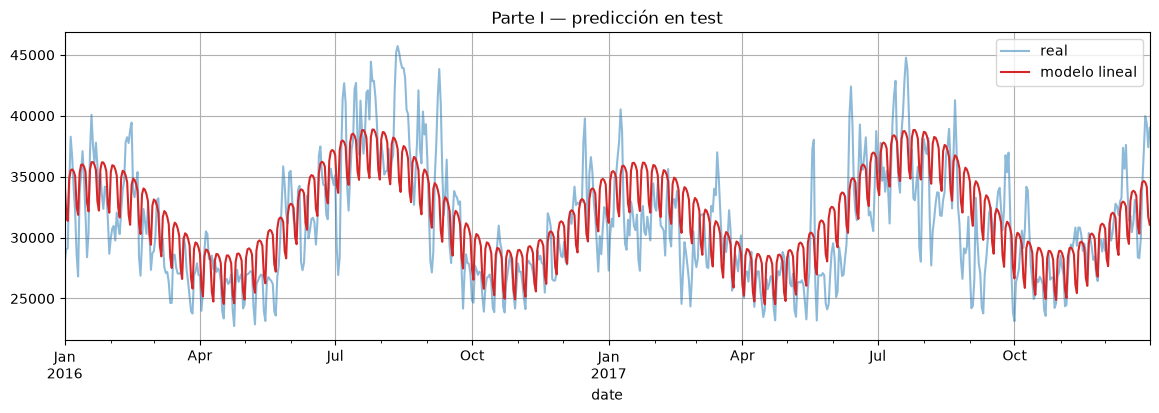

In [12]:
fit_I  = pd.Series(ols_I.predict(X_train), index=y_train.index)
pred_I = pd.Series(ols_I.predict(X_test),  index=y_test.index)
rmse_I_train = rmse(y_train, fit_I)
rmse_I_test  = rmse(y_test,  pred_I)
print(f"RMSE train (ajuste):     {rmse_I_train:,.1f} MW")
print(f"RMSE test  (predicción): {rmse_I_test:,.1f} MW")

fig, ax = plt.subplots()
y_test.plot(ax=ax, alpha=0.5, label='real')
pred_I.plot(ax=ax, color='C3', label='modelo lineal')
ax.set_title('Parte I — predicción en test'); ax.legend();

**Diagnóstico de residuos (train).** Si los residuos fueran ruido blanco, la regresión bastaría. Lo chequeamos como en el curso: gráfico temporal, QQ-plot (gaussianidad), ACF y PACF.

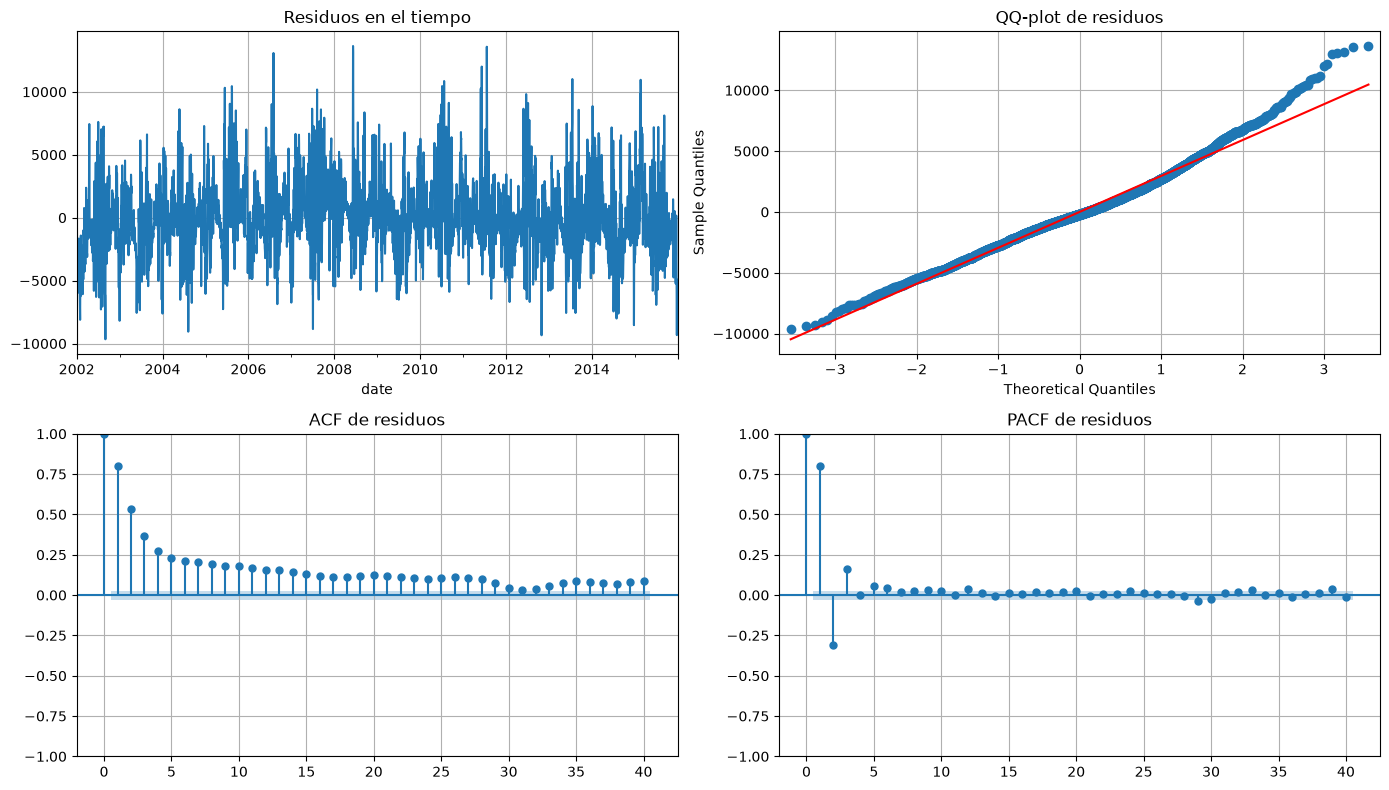

In [13]:
resid_I = y_train - fit_I
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
resid_I.plot(ax=axes[0,0], title='Residuos en el tiempo')
sm.qqplot(resid_I, line='s', ax=axes[0,1])
axes[0,1].set_title('QQ-plot de residuos')
plot_acf(resid_I, lags=40, bartlett_confint=False, ax=axes[1,0])
axes[1,0].set_title('ACF de residuos')
plot_pacf(resid_I, lags=40, ax=axes[1,1])
axes[1,1].set_title('PACF de residuos')
plt.tight_layout()

**Conclusión Parte I.** El modelo capta el grueso de la estructura (tendencia + dos picos anuales + calendario semanal) con **RMSE train 2952 MW** y **RMSE test 3288 MW**. Generaliza bien: el error en test es apenas mayor que en train. Pero el diagnóstico muestra que los residuos **no son ruido blanco**: la ACF decae lentamente desde 0.80, el QQ-plot muestra colas pesadas, y en el gráfico temporal se ven rachas de varios días (olas de frío/calor).

## Parte II — Modelos con correlación interna

El modelo de regresión de la Parte I no tiene en cuenta la estructura de autocorrelación de los residuos. Buscamos ahora incorporar una componente ARMA a los mismos.

 * Analice los residuos del ajuste anterior, en particular su estructura de correlación.
 * En base a dicho análisis, proponga un modelo $ARMA(p,q)$ adecuadamente justificado (puede probar más de uno para comparar).
 * Realice el ajuste sobre los residuos y haga un diagnóstico sobre el ajuste realizado.

### Solución — Parte II

Para identificar el orden: en un **AR($p$)** la PACF *corta* después del lag $p$ y la ACF decae exponencialmente; en un **MA($q$)** la ACF corta después de $q$; si ambas decaen sin un corte claro, el proceso es ARMA mixto y "no queda otra que probar" comparando por **AIC/BIC**. Trabajamos sobre los residuos de train de la Parte I, con `trend='n'` porque ya están centrados (media 0 por construcción del OLS).

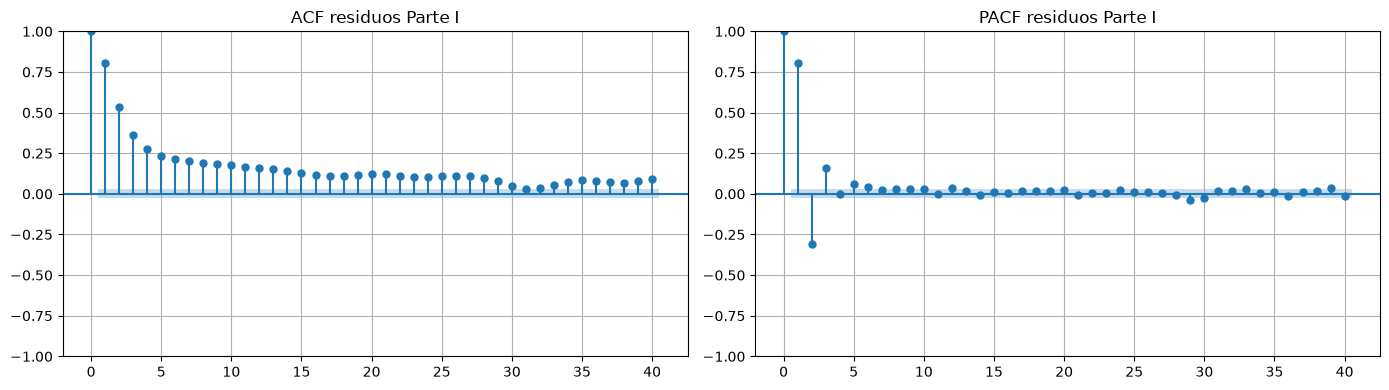

In [14]:
# ACF / PACF de los residuos de la Parte I
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(resid_I, lags=40, bartlett_confint=False, ax=axes[0])
axes[0].set_title('ACF residuos Parte I')
plot_pacf(resid_I, lags=40, ax=axes[1])
axes[1].set_title('PACF residuos Parte I')
plt.tight_layout()

La ACF decae de forma aproximadamente exponencial desde 0.80 sin cortarse — el patrón típico de un proceso **autorregresivo**. La PACF, en cambio, tiene tres lags claramente dominantes ($0.80$, $-0.31$, $0.16$) y del cuarto en adelante quedan valores muy chicos, varios apenas por encima de la banda. La lectura ACF/PACF sugiere entonces un **AR(3)**. Como el corte no es perfectamente limpio, probamos también variantes mixtas ARMA($p{,}q$) de orden bajo y dejamos que AIC/BIC decida.

In [15]:
# Comparación de órdenes candidatos por AIC/BIC
candidatos = [(1,0,0), (2,0,0), (3,0,0), (1,0,1), (2,0,1)]
tabla = []
for order in candidatos:
    m = ARIMA(resid_I, order=order, trend='n').fit()
    tabla.append({'order': order, 'AIC': m.aic, 'BIC': m.bic})
tabla = pd.DataFrame(tabla).sort_values('AIC').reset_index(drop=True)
print(tabla)
order_II = tabla.loc[0, 'order']
print('Orden seleccionado por AIC:', order_II)

       order           AIC           BIC
0  (3, 0, 0)  90284.106256  90310.264422
1  (1, 0, 1)  90295.039263  90314.657887
2  (2, 0, 1)  90296.328486  90322.486652
3  (2, 0, 0)  90416.582976  90436.201601
4  (1, 0, 0)  90930.867713  90943.946796
Orden seleccionado por AIC: (3, 0, 0)


El **AR(3)** gana tanto por AIC como por BIC, con las variantes mixtas (1,1) y (2,1) unos 11 puntos de AIC detrás — consistente con la lectura de la PACF. AR(1) y AR(2) quedan claramente descartados: los tres primeros lags aportan de verdad.

In [16]:
# Ajuste del modelo seleccionado
arma_II = ARIMA(resid_I, order=order_II, trend='n').fit()
print(arma_II.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 5113
Model:                 ARIMA(3, 0, 0)   Log Likelihood              -45138.053
Date:                Sat, 04 Jul 2026   AIC                          90284.106
Time:                        11:47:40   BIC                          90310.264
Sample:                    01-01-2002   HQIC                         90293.264
                         - 12-31-2015                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.1024      0.011     98.962      0.000       1.081       1.124
ar.L2         -0.4797      0.016    -30.261      0.000      -0.511      -0.449
ar.L3          0.1612      0.012     13.836      0.0

      lb_stat  lb_pvalue
7   14.726888   0.039664
14  43.585406   0.000069
21  56.822824   0.000038
30  77.109737   0.000005


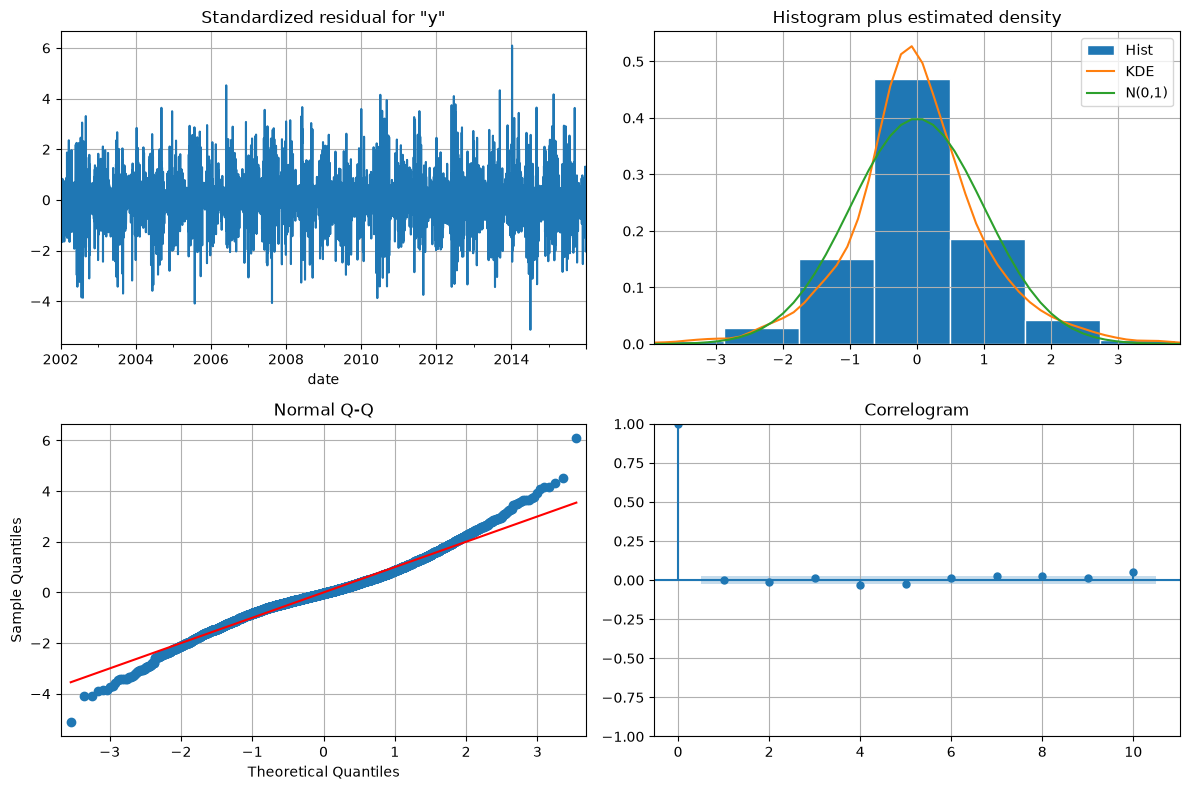

In [17]:
# Diagnóstico: residuos estandarizados, histograma, QQ y correlograma + test de Ljung-Box
arma_II.plot_diagnostics(figsize=(12, 8)); plt.tight_layout()
# descartamos los primeros p residuos, afectados por la inicialización del filtro
res_II = arma_II.resid.iloc[order_II[0]:]
print(acorr_ljungbox(res_II, lags=[7, 14, 21, 30], return_df=True))

**Diagnóstico y conclusión Parte II.** El AR(3) estimado ($\hat\phi \approx (1.10,\, -0.48,\, 0.16)$, todos muy significativos) reduce drásticamente la autocorrelación: los residuos pasan de una ACF que arrancaba en 0.80 a correlaciones de a lo sumo **0.05 en valor absoluto** en los primeros 30 lags, y el correlograma del diagnóstico queda casi todo dentro de las bandas.

**Ljung–Box rechaza blancura estricta** ($p=0.04$ acumulando 7 lags, $p<10^{-4}$ a 14–30 lags). No hay contradicción: con $n\approx 5100$ el test tiene potencia para detectar correlaciones de apenas 0.03–0.05, que es exactamente lo que queda — estructura fina asociada a rachas climáticas de varios días y a feriados que el calendario no modela; información real pero de magnitud casi irrelevante para la predicción. La conclusión no es "los residuos quedaron blancos", sino: *el AR(3) extrae prácticamente toda la estructura lineal aprovechable; lo que falta no es más correlación interna sino información exógena (la temperatura)*.

## Parte III — Modelo ARMA con variables exógenas.

Combine los resultados de las partes I y II realizando un ajuste ARMA con variables exógenas, donde las variables exógenas son exactamente los regresores usados en la formulación lineal.

* Analice si el modelo mejora el ajuste respecto a la Parte I.
* Realice un diagnóstico de los residuos finales.
* Calcule la predicción sobre los datos de test y reporte los resultados.

### Solución — Parte III

Unificamos las partes I y II en un único **ARMA con variables exógenas**, usando la clase `ARIMA` de `statsmodels` con el argumento `exog`: las exógenas son **exactamente los regresores de la Parte I** (`build_design`) y el error sigue el ARMA de la Parte II. `trend='n'` porque la constante ya está dentro de las exógenas.

In [18]:
# ARMA con variables exógenas: exactamente los regresores de la Parte I
arimax_III = ARIMA(y_train, exog=X_train, order=order_II, trend='n').fit()
print(arimax_III.summary())

                               SARIMAX Results                                
Dep. Variable:             consumo_MW   No. Observations:                 5113
Model:                 ARIMA(3, 0, 0)   Log Likelihood              -45138.053
Date:                Sat, 04 Jul 2026   AIC                          90308.106
Time:                        11:47:42   BIC                          90412.739
Sample:                    01-01-2002   HQIC                         90344.737
                         - 12-31-2015                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        3.32e+04    233.110    142.402      0.000    3.27e+04    3.37e+04
trend        -45.0196     26.292     -1.712      0.087     -96.551       6.512
cos1       -1178.8761    145.291     -8.114      0.0

**Lectura del ajuste.** Las betas de las exógenas quedan prácticamente idénticas a las del OLS de la Parte I, y los coeficientes AR coinciden con los de la Parte II — el modelo unificado es coherente con el camino en dos etapas (regresión primero, ARMA sobre residuos después).

**La tendencia deja de ser significativa** ($z=-1.71$, $p=0.087$, contra $p<0.001$ en el OLS). No es contradicción: la inferencia OLS **supone residuos blancos** y, como no lo eran, sus errores estándar estaban subestimados. Al modelar la autocorrelación los errores estándar se vuelven honestos, y la evidencia de tendencia queda apenas marginal. La mantenemos en el modelo (la letra pide explorar la tendencia y su efecto es pequeño), pero dejamos anotado que su significancia en la Parte I era en parte un espejismo de la autocorrelación. Lo mismo le ocurre a `viernes` ($p=0.62$), coherente con lo visto en la Parte I.

In [19]:
# Ajuste in-sample (predicción a un paso) y comparación con la Parte I
fit_III = arimax_III.fittedvalues
rmse_III_train = rmse(y_train, fit_III)

# Predicción a horizonte largo en test (las exógenas son determinísticas: calculables para cualquier fecha)
pred_III = arimax_III.get_prediction(start=y_test.index[0], end=y_test.index[-1], exog=X_test).predicted_mean
rmse_III_test = rmse(y_test, pred_III)

# Predicción recursiva a un paso: agregamos los datos de test al modelo SIN reajustar (fit.append, como en el curso)
arimax_III_rec = arimax_III.append(y_test, exog=X_test)
pred_III_rec = arimax_III_rec.get_prediction(start=y_test.index[0], end=y_test.index[-1]).predicted_mean
rmse_III_rec = rmse(y_test, pred_III_rec)

print(f"Parte I   -> RMSE train {rmse_I_train:>9,.1f} | RMSE test {rmse_I_test:>9,.1f}")
print(f"Parte III -> RMSE train {rmse_III_train:>9,.1f} | RMSE test {rmse_III_test:>9,.1f}  (horizonte largo)")
print(f"Parte III -> RMSE test recursivo (a un paso): {rmse_III_rec:,.1f}")

Parte I   -> RMSE train   2,952.1 | RMSE test   3,288.3
Parte III -> RMSE train   1,651.8 | RMSE test   3,277.2  (horizonte largo)
Parte III -> RMSE test recursivo (a un paso): 1,750.7


**Interpretación.** Hay que separar dos usos del modelo, como se vio en el curso:

* **Ajuste / predicción a un paso:** el RMSE baja de 2952 (Parte I) a **1652 MW**: conociendo los últimos días, la componente AR corrige la predicción del día siguiente y reduce el error un 44%. En test, la versión **recursiva** (`fit.append`, que incorpora cada dato nuevo *sin reajustar parámetros*) confirma la ganancia: **1751 MW**.
* **Predicción a horizonte largo** (los 2 años de test predichos de una vez): el RMSE queda en **3277 MW**, casi igual que la Parte I (3288). Es lo esperable: la componente AR revierte a la media en unas pocas semanas, y a dos años vista solo sobrevive la parte determinística — que es la misma de la Parte I.

En resumen: **el ARMA mejora mucho el corto plazo y casi nada el largo plazo**.

      lb_stat  lb_pvalue
7   14.726891   0.039664
14  43.585405   0.000069
21  56.822822   0.000038
30  77.109734   0.000005


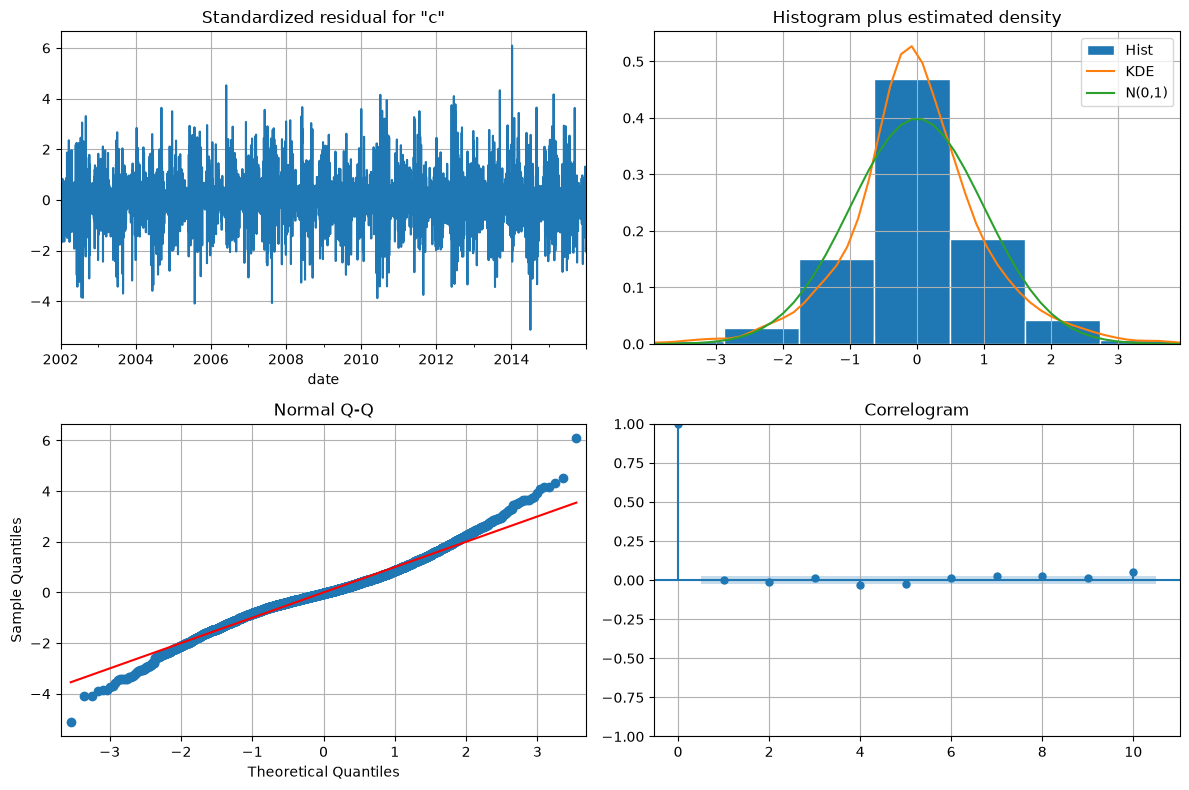

In [20]:
# Diagnóstico de los residuos finales
arimax_III.plot_diagnostics(figsize=(12, 8)); plt.tight_layout()
res_III = arimax_III.resid.iloc[order_II[0]:]
print(acorr_ljungbox(res_III, lags=[7, 14, 21, 30], return_df=True))

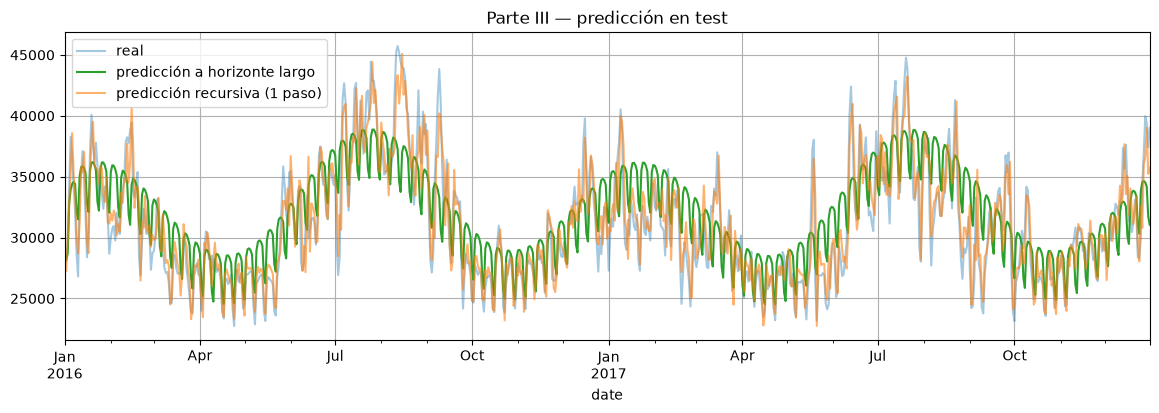

In [21]:
fig, ax = plt.subplots()
y_test.plot(ax=ax, alpha=0.4, label='real')
pred_III.plot(ax=ax, color='C2', label='predicción a horizonte largo')
pred_III_rec.plot(ax=ax, color='C1', alpha=0.6, label='predicción recursiva (1 paso)')
ax.set_title('Parte III — predicción en test'); ax.legend();

**Diagnóstico final y conclusión Parte III.** Los residuos del modelo unificado son, como era de esperar, esencialmente los mismos de la Parte II: correlaciones remanentes $\leq 0.05$ y **Ljung–Box rechazando blancura estricta** ($p=0.04$ a 7 lags, $p<10^{-4}$ a 14+), por las razones ya discutidas (el test es muy potente con $n$ grande; quedan rachas climáticas y feriados sin modelar). El modelo ajusta mucho mejor a un paso (1652 vs 2952), predice en test a horizonte largo igual que la Parte I (3277 vs 3288) y mucho mejor en modo recursivo (1751).

## Parte IV — Modelo en espacio de estados

Consideramos ahora un enfoque por modelos estructurales para la serie. Para toda esta parte conviene trabajar con la serie *centrada*, restando la media.

1. En primer lugar se propone un modelo de la forma *local level* de ruido $w_t$ más una componente estacional:
   \begin{align*}
   x_{t+1} &= x_t + \overbrace{\eta_t}^{\text{level noise}} \\
   y_t &= x_t + s_t + \underbrace{\varepsilon_t}_{\text{irregular noise}}
   \end{align*}
   donde $s_t$ es una componente estacional de corto plazo que modela la variación intrasemanal. Es decir $\sum_{j=0}^6 s_{t-j} = w_t$, con $w_t$ el ruido blanco estacional (seasonal noise) y $\varepsilon_t$ el ruido blanco de observación (irregular noise).
   Esto puede hacerse mediante `UnobservedComponents` pasando como parámetros `seasonal=7` y `stochastic_seasonal=True`.
   Ajuste este modelo y observe que la componente de tendencia está intentando trackear la variación anual.

3. Mejore el modelo anterior incorporando una componente *determinística* de frecuencia como la de la parte I (cosenos y senos de frecuencia adecuada). Es decir:
   \begin{align*}
   x_{t+1} &= \mu \\
   y_t &= x_t + s_t + \gamma_t + \underbrace{\varepsilon_t}_{\text{irregular noise}}
   \end{align*}
   donde $\mu$ es un nivel determinístico, $s_t$ es como antes y $\gamma_t$ son los cosenos y senos de la parte I.

   Esto puede hacerse mediante `UnobservedComponents` agregando como parámetros `freq_seasonal=[{'period': 365.25, 'harmonics': k}]` donde $k$ es la cantidad de componentes de frecuencia, y `stochastic_freq_seasonal=[False]`. Para la componente determinística puede usarse `level=True, stochastic_level=False`. Verifique que la performance de este modelo es comparable a la de la regresión lineal de la parte I, y el residuo aún no queda blanco.


4. Incorpore una componente autorregresiva al modelo cambiando la parte `irregular` por una autorregresiva, es decir:
    \begin{align*}
   x_{t+1} &= \mu \\
   y_t &= x_t + s_t + \gamma_t + \underbrace{\varepsilon_t}_{\text{autoregressive noise}}
   \end{align*}
   donde ahora $\varepsilon_t$ es un proceso autorregresivo de orden similar al de la parte II. Para ello puede colocar como parámetros `irregular=False` y `autorregresive=k` con $k$ adecuado.


5. Compare este último modelo con el obtenido en la parte III en los datos de test y discuta.

### Solución — Parte IV

Enfoque estructural con `UnobservedComponents`, sobre la serie **centrada** (restamos la media de train, como indica la letra). Ajustamos tres modelos incrementales (A, B y C) y comparamos el último contra la Parte III en test.

In [22]:
mu = y_train.mean()
yc_train = y_train - mu
print('Media de train (mu):', round(mu, 1))

Media de train (mu): 32246.9


**Modelo A — *local level* + estacional semanal estocástico** (punto 1 de la letra). El único componente de baja frecuencia disponible es el nivel.

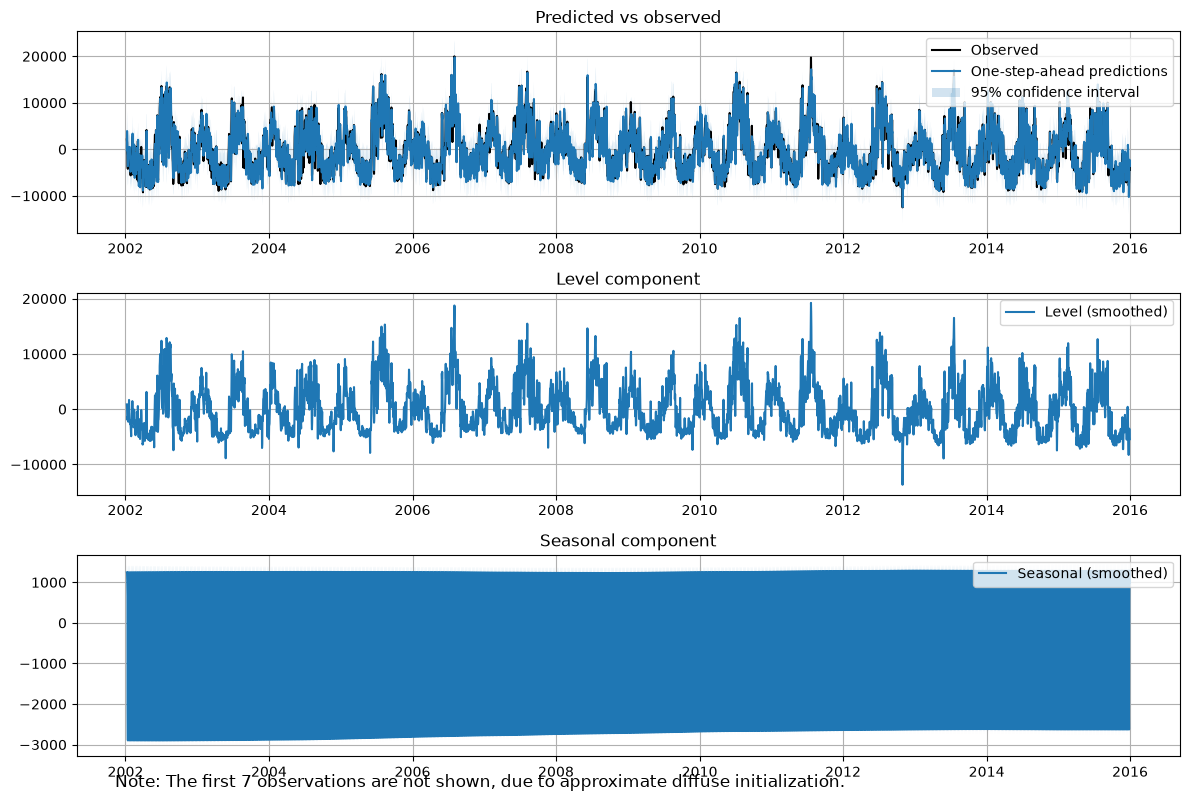

In [23]:
ucA = UnobservedComponents(yc_train, level='local level',
                           seasonal=7, stochastic_seasonal=True).fit(disp=False)
ucA.plot_components(figsize=(12, 8)); plt.tight_layout()

**Observación:** en el gráfico de componentes, el *nivel* no queda constante: sube y baja siguiendo el ciclo **anual** de la serie. Como el modelo no tiene ninguna componente anual, el nivel local (un paseo al azar) es lo único que puede *trackear* esa variación lenta. La componente `seasonal` capta la variación intrasemanal.

**Modelo B — nivel determinístico + estacional semanal + frecuencia anual determinística** (punto 3 de la letra): el ciclo anual pasa a estar modelado por senos/cosenos determinísticos (`freq_seasonal` con $k=2$, como la Parte I) y el nivel deja de ser estocástico (`level=True, stochastic_level=False`).

Modelo B -> RMSE train (a un paso) 2,984.0   |   Parte I: 2,952.1


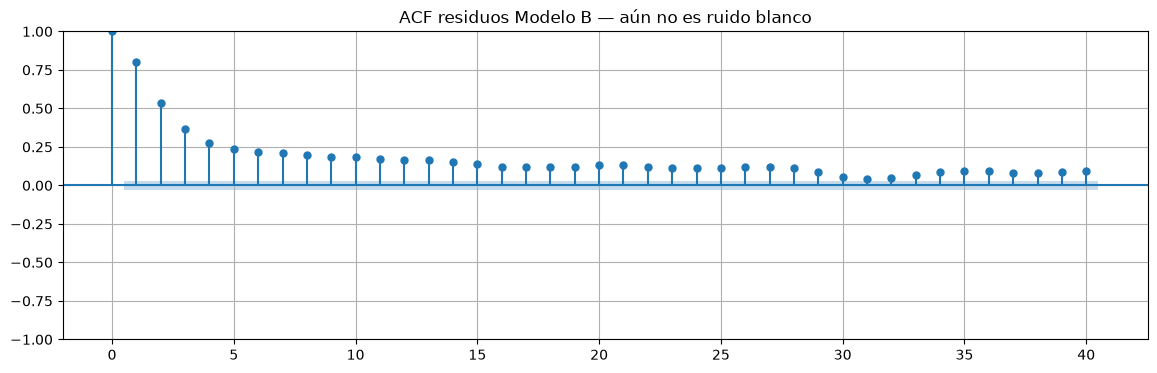

In [24]:
ucB = UnobservedComponents(yc_train, level=True, stochastic_level=False,
                           seasonal=7, stochastic_seasonal=True,
                           freq_seasonal=[{'period': 365.25, 'harmonics': 2}],
                           stochastic_freq_seasonal=[False],
                           irregular=True).fit(disp=False)
fit_B = ucB.fittedvalues + mu
rmse_B_train = rmse(y_train, fit_B)
print(f"Modelo B -> RMSE train (a un paso) {rmse_B_train:,.1f}   |   Parte I: {rmse_I_train:,.1f}")
# ACF de los residuos: descartamos los primeros valores, afectados por la inicialización difusa del filtro
plot_acf(ucB.resid.iloc[10:], lags=40, bartlett_confint=False)
plt.title('ACF residuos Modelo B — aún no es ruido blanco');

El RMSE de train del Modelo B (**2984 MW**, predicción a un paso) es comparable al de la regresión de la Parte I (**2952 MW**). Tiene sentido: ambos modelan la misma estructura — nivel + calendario semanal + ciclo anual determinístico — uno por espacio de estados y el otro por regresión. Y la ACF de sus residuos muestra el mismo decaimiento lento desde ~0.8: **el residuo aún no queda blanco**, tal como anticipa la letra. Falta modelar la correlación de corto plazo, que es justamente el Modelo C.

**Modelo C — ruido autorregresivo** (punto 4): se sustituye el ruido irregular por un proceso AR (`irregular=False, autoregressive=k`), con $k$ igual al orden AR de la Parte II. Con datos diarios y armónicos anuales este ajuste es exigente, por lo que subimos `maxiter` y **verificamos explícitamente la convergencia** del optimizador.

In [25]:
ucC = UnobservedComponents(yc_train, level=True, stochastic_level=False,
                           seasonal=7, stochastic_seasonal=True,
                           freq_seasonal=[{'period': 365.25, 'harmonics': 2}],
                           stochastic_freq_seasonal=[False],
                           irregular=False, autoregressive=int(order_II[0])).fit(disp=False, maxiter=500)
print('¿La optimización convergió? ->', ucC.mle_retvals['converged'])
pred_IV = ucC.get_prediction(start=y_test.index[0], end=y_test.index[-1]).predicted_mean + mu
rmse_IV_test = rmse(y_test, pred_IV)
print(f"Parte IV (UC + AR)          -> RMSE test {rmse_IV_test:,.1f}")
print(f"Parte III (ARMA + exógenas) -> RMSE test {rmse_III_test:,.1f}")

¿La optimización convergió? -> True
Parte IV (UC + AR)          -> RMSE test 3,391.5
Parte III (ARMA + exógenas) -> RMSE test 3,277.2


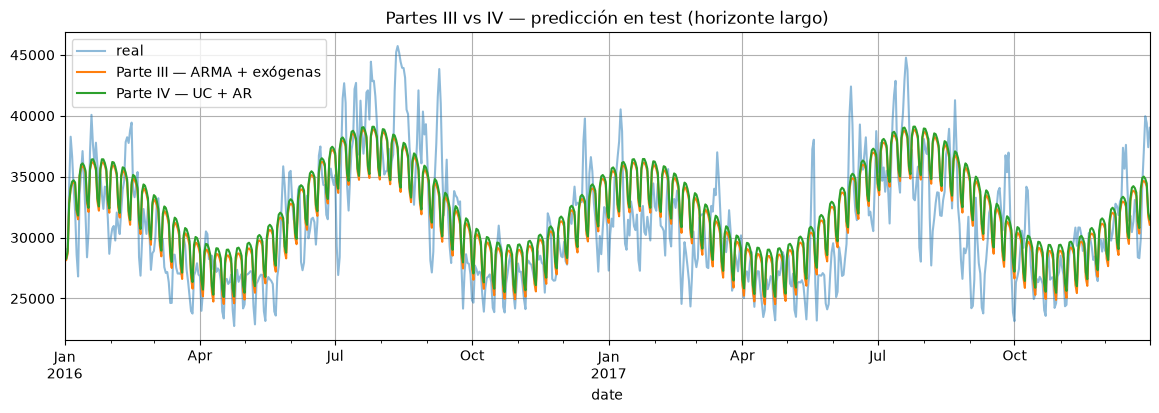

In [26]:
fig, ax = plt.subplots()
y_test.plot(ax=ax, alpha=0.5, label='real')
pred_III.plot(ax=ax, label='Parte III — ARMA + exógenas')
pred_IV.plot(ax=ax, label='Parte IV — UC + AR')
ax.set_title('Partes III vs IV — predicción en test (horizonte largo)'); ax.legend();

**Conclusión Parte IV.** La optimización del Modelo C **convergió** y su predicción a horizonte largo en test da **RMSE 3392 MW**, comparable a los **3277 MW** de la Parte III. Es razonable: ambos modelos representan la misma estructura — nivel + estacionalidad semanal + ciclo anual determinístico + error AR(3) — por dos caminos distintos (regresión con error ARMA vs. espacio de estados con filtro de Kalman).

## Parte V — Correlación con temperatura

El consumo eléctrico está fuertemente influenciado por la temperatura: el frío aumenta la demanda de calefacción, el calor aumenta la de refrigeración. En esta parte se estudia cuantitativamente esa relación y se evalúa si incorporar temperatura mejora la predicción. Para ello disponemos como referencia los datos de temperatura de Philadelphia, en el centro de la zona de influencia de PJM-East.

In [27]:
temp = pd.read_csv('data/philadelphia_temp.csv', parse_dates=['date'], index_col='date')
print(f"Temperatura cargada: {len(temp)} días")

temp.head()

Temperatura cargada: 5844 días


,temp_C,temp_max_C,temp_min_C
date,,,
2002-01-01,-3.3,1.3,-6.6
2002-01-02,-2.4,2.3,-5.7
2002-01-03,-1.2,3.1,-4.0
2002-01-04,-0.4,3.6,-2.6
2002-01-05,1.2,5.8,-1.4


<Axes: xlabel='date'>

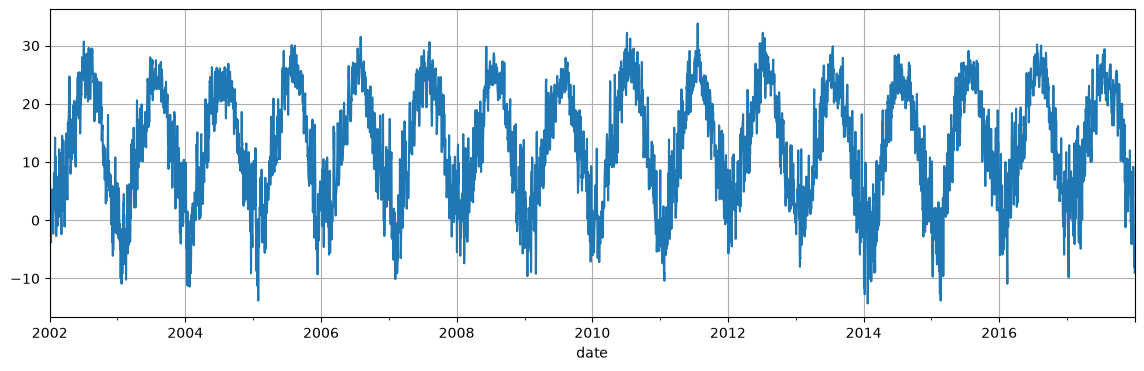

In [28]:
temp["temp_C"].plot()

1. Grafique simultáneamente ambas series para ver su comportamiento conjunto.
2. Estudie la correlación a lag 0 entre $P_t=pjme_t$ y $T_t=temp_t$. ¿Es alta la correlación?
3. Realice un scatter plot entre $pjme_t$ y $temp_t$ para ver que hay dependencia *no lineal* más allá de su baja correlación. Interprete el resultado.
4. Para modelar lo anterior, construya una variable explicativa *desvío térmico*, por ejemplo de la forma $\delta_t = |T_t - \bar{T}_t|$.
5. Realice un ajuste por modelo lineal de la forma:
   $$x_t = \beta_0 + \beta_1 \delta_t + \beta_2 d_t + w_t$$
   siendo $d_t$ la dummy de fin de semana y $w_t$ ruido blanco. ¿Cómo se compara este modelo con los anteriores?
6. Proponga formas alternativas de modelar el desvío térmico y/o la variación temporal para mejorar aún más el modelo.

### Solución — Parte V

Siguiendo las consignas de la letra: comportamiento conjunto, correlación a lag 0, scatter, desvío térmico, modelo lineal con $\delta_t$ y $d_t$, y mejoras.

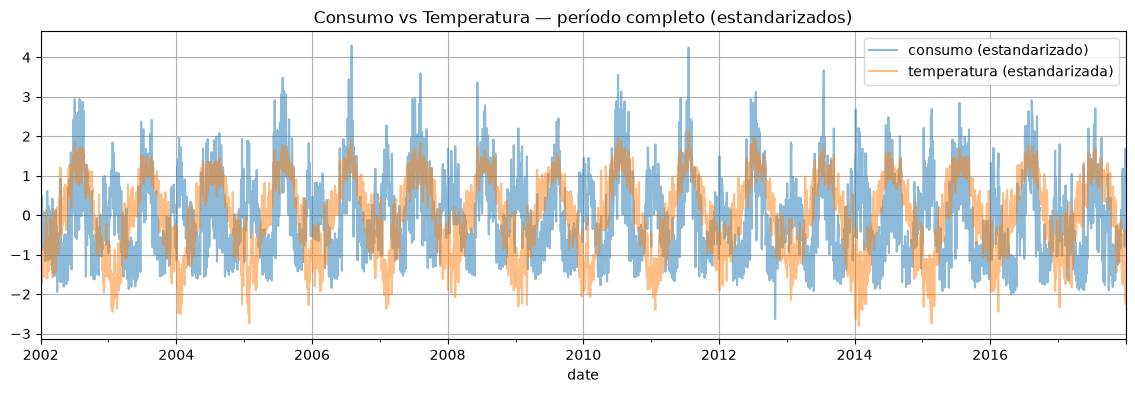

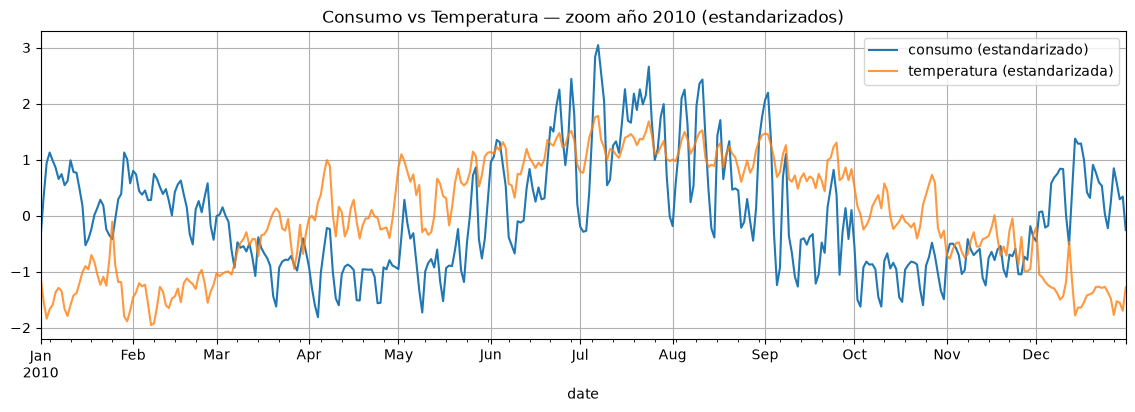

In [29]:
T = temp['temp_C']
z = lambda s: (s - s.mean()) / s.std()   # estandarizo para poder ver ambas series en la misma escala

# 1) Comportamiento conjunto: período completo y zoom a un año
fig, ax = plt.subplots()
z(pjme).plot(ax=ax, alpha=0.5, label='consumo (estandarizado)')
z(T).plot(ax=ax, alpha=0.5, label='temperatura (estandarizada)')
ax.set_title('Consumo vs Temperatura — período completo (estandarizados)'); ax.legend();

fig, ax = plt.subplots()
z(pjme['2010']).plot(ax=ax, label='consumo (estandarizado)')
z(T['2010']).plot(ax=ax, alpha=0.8, label='temperatura (estandarizada)')
ax.set_title('Consumo vs Temperatura — zoom año 2010 (estandarizados)'); ax.legend();

Correlación a lag 0 entre consumo y temperatura: 0.173


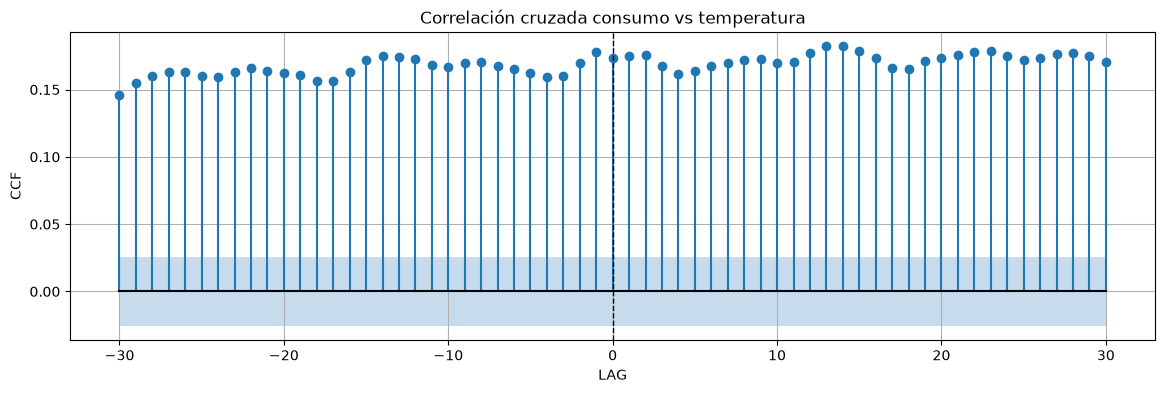

In [30]:
# 2) Correlación a lag 0 y correlación cruzada (función del curso)
corr0 = np.corrcoef(pjme.values, T.values)[0, 1]
print(f"Correlación a lag 0 entre consumo y temperatura: {corr0:.3f}")
plt.figure()
ccf(pjme.values, T.values, max_lag=30)
plt.title('Correlación cruzada consumo vs temperatura');

Vistas juntas, las dos series comparten el mismo calendario: la temperatura marca el ciclo anual y el consumo lo sigue. Pero el zoom muestra el detalle clave: el consumo sube tanto en los **valles** de temperatura (invierno) como en los **picos** (verano). La correlación a lag 0 es **0.173: baja**, y la CCF muestra valores igual de bajos en todos los lags — es decir, no es que la relación exista pero esté "corrida" a otro lag: la dependencia **no es lineal**, como confirma el scatter siguiente.

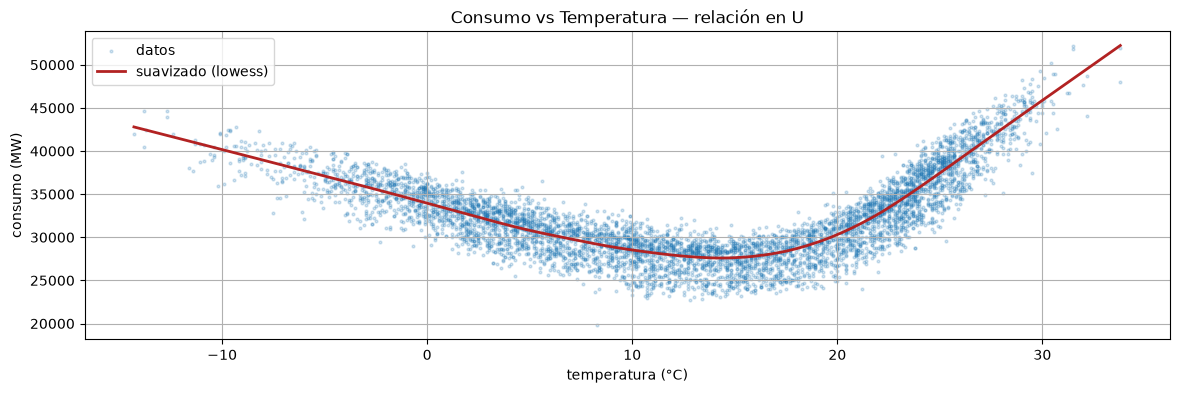

In [ ]:
# 3) Scatter consumo vs temperatura, con un suavizado local
plt.figure()
plt.scatter(T, pjme, s=4, alpha=0.2, label='datos')
low = sm.nonparametric.lowess(pjme.values, T.values, frac=0.3)
plt.plot(low[:, 0], low[:, 1], color='firebrick', linewidth=2, label='suavizado (lowess)')
plt.xlabel('temperatura (°C)'); plt.ylabel('consumo (MW)')
plt.title('Consumo vs Temperatura — relación en U'); plt.legend();

La correlación lineal es baja **porque la relación no es lineal sino en forma de U**: tanto el frío (calefacción) como el calor (refrigeración) aumentan el consumo, y al correlacionar linealmente ambos efectos, de signo opuesto, se cancelan. El suavizado sobre el scatter muestra el mínimo de consumo en temperaturas templadas.

In [32]:
# 4) Desvío térmico: delta = |T - T_ref|, con T_ref = temperatura media en train (como sugiere la letra)
T_ref = T.loc[y_train.index].mean()
print(f"Temperatura de referencia (media en train): {T_ref:.1f} °C")
delta = (T - T_ref).abs()

Temperatura de referencia (media en train): 12.9 °C


**Numeral 5 — modelo lineal de la letra:** $x_t = \beta_0 + \beta_1\,\delta_t + \beta_2\,d_t + w_t$, con $d_t$ la **dummy de fin de semana** (seguimos la fórmula tal cual la da la letra; en la Parte I habíamos generalizado el efecto calendario a un factor por día).

In [33]:
# 5) Modelo lineal: consumo ~ delta + dummy fin de semana
def build_temp_design(index):
    X = pd.DataFrame(index=index)
    X['const']   = 1.0
    X['delta']   = delta.loc[index].values
    X['weekend'] = (index.dayofweek >= 5).astype(float)
    return X

Xt_train, Xt_test = build_temp_design(y_train.index), build_temp_design(y_test.index)
ols_V = sm.OLS(y_train, Xt_train).fit()
print(ols_V.summary())
rmse_V_train = rmse(y_train, ols_V.predict(Xt_train))
rmse_V_test  = rmse(y_test,  ols_V.predict(Xt_test))
print(f"\nParte V (delta + finde) -> RMSE train {rmse_V_train:,.1f} | RMSE test {rmse_V_test:,.1f}")

                            OLS Regression Results                            
Dep. Variable:             consumo_MW   R-squared:                       0.760
Model:                            OLS   Adj. R-squared:                  0.759
Method:                 Least Squares   F-statistic:                     8072.
Date:                Sat, 04 Jul 2026   Prob (F-statistic):               0.00
Time:                        11:47:58   Log-Likelihood:                -46789.
No. Observations:                5113   AIC:                         9.358e+04
Df Residuals:                    5110   BIC:                         9.360e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.677e+04     66.250    404.003      0.0

**¿Cómo se compara con los anteriores?** Muchísimo mejor de lo que sus 3 parámetros sugieren: **RMSE test 2419 MW**, contra 3288 de la Parte I y 3277 de la Parte III (modelos de 12–15 parámetros) — una mejora de ~26%. El $R^2$ sube a 0.76 (era 0.60 en la Parte I). La razón: los picos de consumo los produce la **temperatura real** de cada año; el calendario solo puede prometer que "el 15 de julio *suele* ser caluroso", mientras que $\delta_t$ ve la ola de calor directamente.

**Aclaración importante para la comparación:** las Partes I–IV predicen test usando solo funciones determinísticas de la fecha (calculables a futuro), mientras que este modelo usa la **temperatura observada** del período de test, que en un pronóstico real a dos años no se conoce. La comparación vale como evaluación *condicional a la temperatura* (equivalente a asumir un pronóstico meteorológico perfecto); es lo que pide la letra, pero corresponde dejarlo explícito.

**Numeral 6**

1. **Respuesta asimétrica al frío y al calor.** El desvío absoluto $\delta_t$ impone la misma pendiente a ambos lados de $\bar{T}$, pero la calefacción y la refrigeración no tienen por qué responder igual. Separamos $\delta_t$ en *desvío frío* $\max(0,\bar{T}-T_t)$ y *desvío calor* $\max(0,T_t-\bar{T})$, similar a lo visto en SOI/Recruitment.
2. **Incorporar la temperatura al modelo de la Parte III** como exógenas adicionales: el ARMA con exógenas ya modela tendencia, estacionalidad y autocorrelación; el desvío térmico le agrega la información física que el calendario no tiene.

In [34]:
# 6a) Respuesta asimétrica: desvío frío y desvío calor (dos pendientes)
def build_frio_calor(index):
    Tt = T.loc[index]
    X = pd.DataFrame(index=index)
    X['const']   = 1.0
    X['frio']    = np.maximum(0.0, T_ref - Tt).values   # desvío frío  (HDD)
    X['calor']   = np.maximum(0.0, Tt - T_ref).values   # desvío calor (CDD)
    X['weekend'] = (index.dayofweek >= 5).astype(float)
    return X

Xa_train, Xa_test = build_frio_calor(y_train.index), build_frio_calor(y_test.index)
ols_Va = sm.OLS(y_train, Xa_train).fit()
print(ols_Va.params.round(1))
rmse_Va_train = rmse(y_train, ols_Va.predict(Xa_train))
rmse_Va_test  = rmse(y_test,  ols_Va.predict(Xa_test))
print(f"Asimétrico (frío/calor + finde) -> RMSE train {rmse_Va_train:,.1f} | RMSE test {rmse_Va_test:,.1f}")

const      26450.8
frio         662.2
calor        931.3
weekend    -3229.0
dtype: float64
Asimétrico (frío/calor + finde) -> RMSE train 1,870.9 | RMSE test 2,164.1


In [35]:
# 6b) La mejora más valiosa: desvío térmico como exógena adicional del modelo de la Parte III.
# Con 14 exógenas + AR(3) la optimización es exigente: inicializamos en dos etapas
# (OLS para las exógenas y ARMA sobre sus residuos, como en el curso) y verificamos convergencia.
Xexo_train = pd.concat([X_train, Xa_train[['frio', 'calor']]], axis=1)
Xexo_test  = pd.concat([X_test,  Xa_test[['frio', 'calor']]],  axis=1)

ols_ini  = sm.OLS(y_train, Xexo_train).fit()
arma_ini = ARIMA(ols_ini.resid, order=order_II, trend='n').fit()
start = np.r_[ols_ini.params.values, arma_ini.params.values]

arimax_V = ARIMA(y_train, exog=Xexo_train, order=order_II, trend='n').fit(
    start_params=start, method_kwargs={'maxiter': 500})
print('¿La optimización convergió? ->', arimax_V.mle_retvals['converged'])
print('Coeficientes de temperatura :', {k: round(v, 1) for k, v in arimax_V.params[['frio', 'calor']].items()})

# Predicción a horizonte largo (comparable con las partes anteriores)
pred_V2 = arimax_V.get_prediction(start=y_test.index[0], end=y_test.index[-1], exog=Xexo_test).predicted_mean
rmse_V2_test = rmse(y_test, pred_V2)

# Predicción recursiva a un paso (el terreno natural de la parte AR)
arimax_V_rec = arimax_V.append(y_test, exog=Xexo_test)
pred_V2_rec = arimax_V_rec.get_prediction(start=y_test.index[0], end=y_test.index[-1]).predicted_mean
rmse_V2_rec = rmse(y_test, pred_V2_rec)

print(f"ARMA + exógenas + temperatura   -> RMSE test {rmse_V2_test:,.1f} (horizonte largo) | {rmse_V2_rec:,.1f} (recursivo)")
print(f"ARMA + exógenas sin temperatura -> RMSE test {rmse_III_test:,.1f} (horizonte largo) | {rmse_III_rec:,.1f} (recursivo)")

¿La optimización convergió? -> True
Coeficientes de temperatura : {'frio': 382.1, 'calor': 726.2}
ARMA + exógenas + temperatura   -> RMSE test 2,540.5 (horizonte largo) | 1,249.1 (recursivo)
ARMA + exógenas sin temperatura -> RMSE test 3,277.2 (horizonte largo) | 1,750.7 (recursivo)


**Lectura de las mejoras.**

* **Asimetría (6a):** la pendiente de *calor* (**931 MW/°C**) es ~40% mayor que la de *frío* (**662 MW/°C**). El RMSE test baja de 2419 a **2164 MW**: la asimetría existe y aporta.
* **ARMA + exógenas + temperatura (6b):** la optimización **convergió** (verificado; usamos la inicialización en dos etapas OLS→ARMA, la misma idea vista en el curso). A **horizonte largo** da RMSE **2540 MW**: mejor que la Parte III (3277) pero peor que el lineal asimétrico (2164). A dos años subpredice los picos. En cambio, en la predicción **recursiva a un paso** este modelo es lejos el mejor de todo el trabajo: **RMSE test 1249 MW** (contra 1751 sin temperatura).

*El "mejor" modelo depende del horizonte para el que se lo va a usar*.

### Comparación final

RMSE de predicción en test (2016–2017, horizonte largo) de todos los modelos del trabajo.

                                    modelo   RMSE_test
V — Lineal asimétrico (frío/calor + finde) 2164.103001
       V — Lineal (desvío térmico + finde) 2418.959244
         V — ARMA + exógenas + temperatura 2540.475836
                III — ARMA + exógenas de I 3277.178803
      I — Lineal (Fourier + día de semana) 3288.294100
         IV — Espacio de estados (UC + AR) 3391.535579


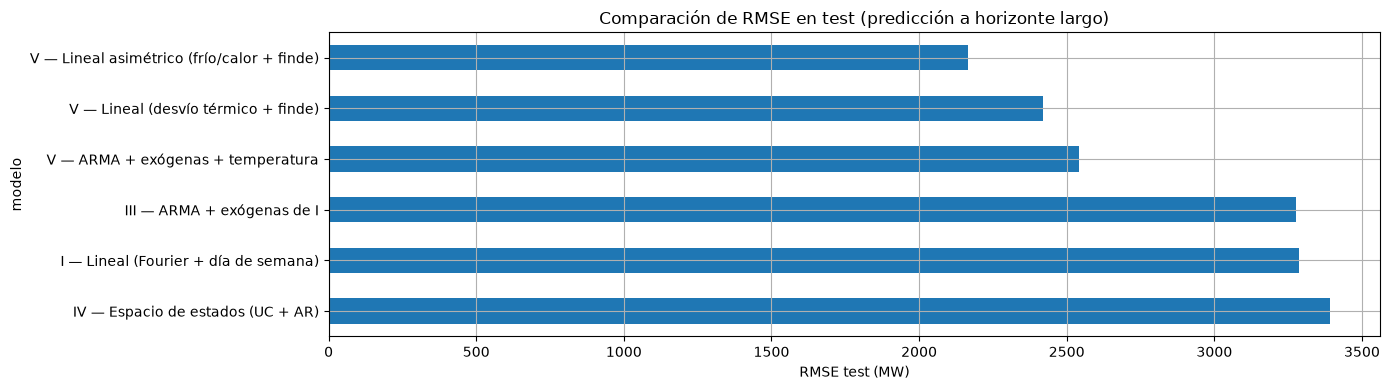

In [36]:
resumen = pd.DataFrame({
    'modelo': ['I — Lineal (Fourier + día de semana)',
               'III — ARMA + exógenas de I',
               'IV — Espacio de estados (UC + AR)',
               'V — Lineal (desvío térmico + finde)',
               'V — Lineal asimétrico (frío/calor + finde)',
               'V — ARMA + exógenas + temperatura'],
    'RMSE_test': [rmse_I_test, rmse_III_test, rmse_IV_test, rmse_V_test, rmse_Va_test, rmse_V2_test]
}).sort_values('RMSE_test').reset_index(drop=True)
print(resumen.to_string(index=False))
resumen.plot.barh(x='modelo', y='RMSE_test', legend=False,
                  title='Comparación de RMSE en test (predicción a horizonte largo)')
plt.gca().invert_yaxis(); plt.xlabel('RMSE test (MW)'); plt.tight_layout();

## Conclusiones generales

A **horizonte largo** (2016–2017 predicho de una vez), el mejor modelo del trabajo es el **lineal asimétrico con temperatura** (frío/calor + fin de semana): **RMSE 2164 MW**, seguido por el ARMA con exógenas + temperatura (2540). En predicción **recursiva a un paso**, el orden cambia: el **ARMA + exógenas + temperatura** es el mejor, con **1249 MW** (1751 sin temperatura).

Tres conclusiones:

1. **La estructura determinística manda a largo plazo:** tendencia + dos armónicos anuales + calendario semanal explican el 60% de la varianza y fijan el piso de ~3300 MW; la componente ARMA (Partes II–IV) casi no mueve ese número porque revierte a la media en semanas.
2. **La temperatura es la información que faltaba:** la relación en U — asimétrica: el calor pesa ~40% más que el frío — reduce el error de largo plazo ~34%. A tener en cuenta: usa temperatura observada, por lo que se necesitaría pronóstico meteorológico.
3. **ARMAX y espacio de estados son dos caras de lo mismo:** las Partes III y IV llegan a resultados equivalentes modelando la misma estructura por caminos distintos.